In [4]:
import cfg
from libs.data_request import DataRequest
from libs.analyzers import SignalStabilityAnalyzer
import matplotlib.pyplot as plt

log = cfg.set_logger()
dr = DataRequest(log=log, base_url=cfg.API_URL)

camp_ids = {'10K': 189, '30K': 190, '100K': 191, '3K': 193}
target_nodes = [1,3,4,5,9]

[IPYKERNEL_LAUNCHER]INFO      Initialized DataRequest class with base_url: https://rsm.ane.gov.co:12443/api


In [5]:
df_full_rb = dr.load_campaigns_and_nodes(campaigns=camp_ids, node_ids=target_nodes)

[IPYKERNEL_LAUNCHER]INFO      Loading data for campaigns: ['10K', '30K', '100K', '3K'] and nodes: [1, 3, 4, 5, 9]

🚀 Starting Campaign: 10K
  ↳ Node 1 loaded instantly from local cache
  ↳ Node 3 loaded instantly from local cache
  ↳ Node 4 loaded instantly from local cache
  ↳ Node 5 loaded instantly from local cache
  ↳ Node 9 loaded instantly from local cache

🚀 Starting Campaign: 30K
  ↳ Node 1 loaded instantly from local cache
  ↳ Node 3 loaded instantly from local cache
  ↳ Node 4 loaded instantly from local cache
  ↳ Node 5 loaded instantly from local cache
  ↳ Node 9 loaded instantly from local cache

🚀 Starting Campaign: 100K
  ↳ Node 1 loaded instantly from local cache
  ↳ Node 3 loaded instantly from local cache
  ↳ Node 4 loaded instantly from local cache
  ↳ Node 5 loaded instantly from local cache
  ↳ Node 9 loaded instantly from local cache

🚀 Starting Campaign: 3K
  ↳ Node 1 loaded instantly from local cache
  ↳ Node 3 loaded instantly from local cache
  ↳ Node 4 loaded

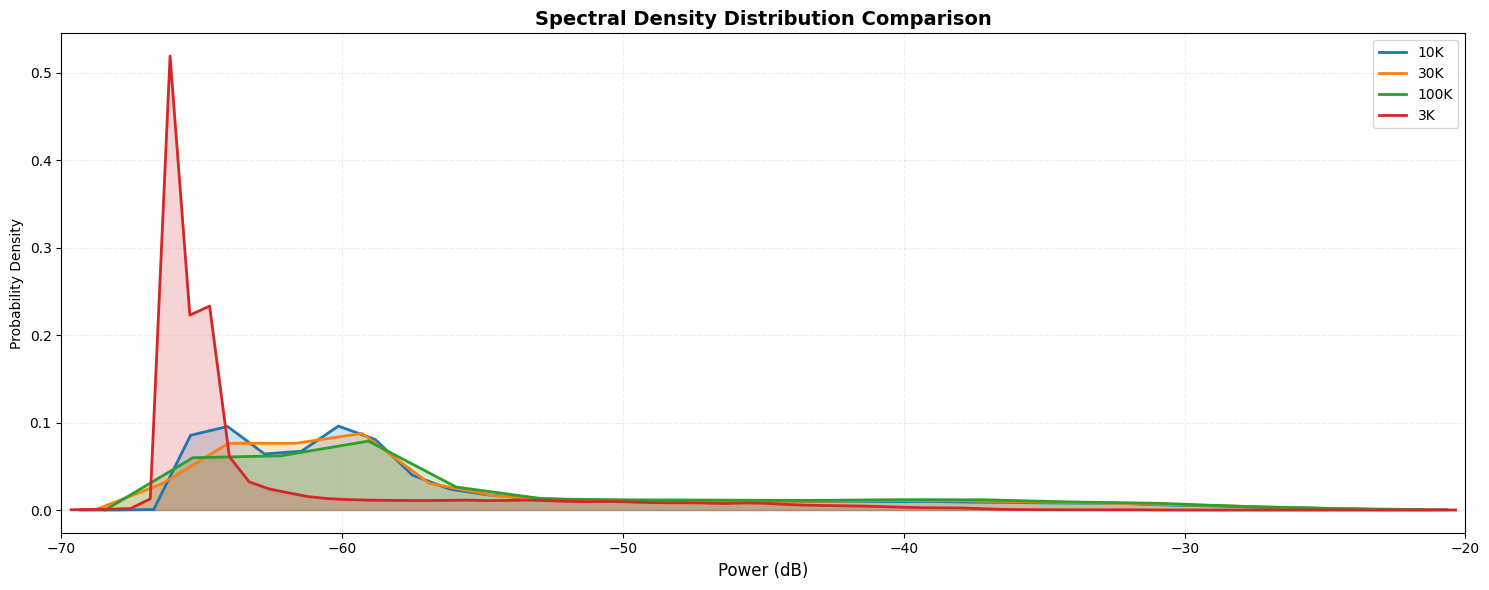

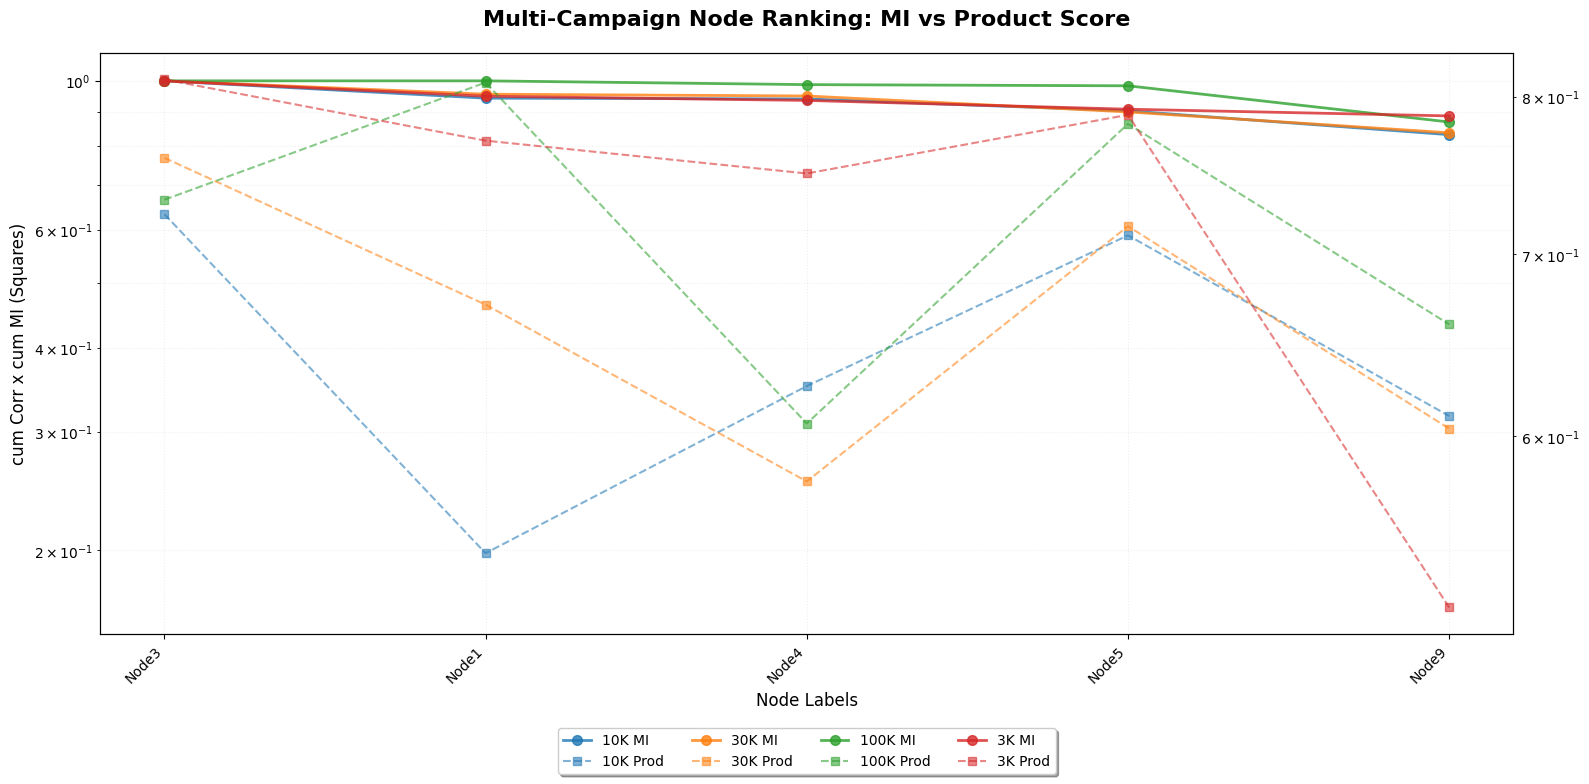

In [6]:
# 1. Calculation Phase
# We initialize the objects and run execute() to compute MI and Correlation
analyzers = {}
for name in camp_ids.keys():
    # Ensure you use the global_range that matches your data
    analyzer = SignalStabilityAnalyzer(df_full_rb[name], global_range=(-70, -20))
    analyzer.execute(alpha=0.5) 
    analyzers[name] = analyzer

# 2. Histogram Overlay (Standard Comparison)
fig1, ax1 = plt.subplots(figsize=(15, 6))
for name, analyzer in analyzers.items():
    # The helper now expects the 'ax' object
    analyzer.plot_hist(ax1, label=name)

ax1.set_title("Spectral Density Distribution Comparison", fontsize=14, fontweight='bold')
ax1.set_xlabel("Power (dB)", fontsize=12)
ax1.set_xlim(-70, -20)
ax1.legend(loc='upper right')
plt.tight_layout()
plt.show()

# 3. Combined Ranking Plot (Dual Axis)
fig, ax_mi = plt.subplots(figsize=(16, 8))
all_lines = []

cmap = plt.get_cmap('tab10')
colors = [cmap(i) for i in range(len(analyzers))]

for i, (name, analyzer) in enumerate(analyzers.items()):
    # This helper manages the twinx() internally and returns line objects for the legend
    lines = analyzer.plot_ranking(ax_mi, label=name, color=colors[i])
    all_lines.extend(lines)

# --- Beauty & Styling ---
ax_mi.set_title("Multi-Campaign Node Ranking: MI vs Product Score", fontsize=16, fontweight='bold', pad=20)
ax_mi.set_xlabel("Node Labels", fontsize=12)
ax_mi.set_ylabel("Cumulative MI (Circles)", fontsize=12)

# Retrieve the automatically created twin axis for the right-side label
ax_prod = ax_mi.get_shared_x_axes().get_siblings(ax_mi)[1]
ax_prod.set_ylabel("cum Corr x cum MI (Squares)", fontsize=12)

# Set matching limits for both axes to keep the visual comparison honest
ax_mi.set_ylim(0.15, 1.1)
ax_prod.set_ylim(0.15, 1.1)

# Generate a clean, unified legend below the plot
labs = [l.get_label() for l in all_lines]
ax_mi.legend(all_lines, labs, loc='upper center', bbox_to_anchor=(0.5, -0.15), 
             ncol=len(analyzers), frameon=True, shadow=True)

ax_mi.grid(True, which='both', alpha=0.2, linestyle=':')
plt.tight_layout()
plt.show()

# 4. Single Campaign Detail (Optional - use when you need the 2-panel view)
# analyzer_3k = analyzers['3K']
# analyzer_3k.execute_one_histogram(campaign_name="3K Detail Analysis")